In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from groupy import * 
from mpl_toolkits.mplot3d import Axes3D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [179]:
def max_filter(templates, X_orbits):
    '''
    X_orbits kxdxn data array 
    templates txd matrix each row is a template
    
    returns max-filter augmented data (torch tensor) 
    '''
    inner_products = torch.einsum('td,kdn->ktn', templates, X_orbits)
    maxes, argmaxes = torch.max(inner_products, axis=0)
    return maxes 

def squared_lipschitz(squared_distance, fX):
    """
    Compute the squared Lipschitz constants (alpha_squared, beta_squared)
    for a mapping fX given the original squared-distance matrix.
    """
    eps = 1e-6
    # 1) Pairwise squared distances in feature space
    fxT = fX.T                                  # (n, target_dim)
    diff = fxT.unsqueeze(1) - fxT.unsqueeze(0)  # (n, n, target_dim)
    fx_sq_dist = (diff ** 2).sum(dim=-1)        # (n, n)

    # 2) Select only unique i < j entries (upper triangle mask)
    mask = torch.triu(torch.ones_like(squared_distance), diagonal=1).bool()
    orig_sq   = squared_distance[mask]          # (n*(n-1)/2,)
    mapped_sq = fx_sq_dist[mask]                # (n*(n-1)/2,)

    # 3) Compute expansion factors safely
    expansions = mapped_sq / (orig_sq + eps)

    # 4) Return min and max
    alpha_squared = expansions.min()
    beta_squared  = expansions.max()
    return alpha_squared, beta_squared

## FOR NON-GROUP INVARIANT ARCHITECTURE

def mask_ignore_block_diagonals(n, k, device=None):
    nk = n * k
    idx = torch.arange(nk, device=device)
    # base mask: False when in same block diagonal (i % n == j % n)
    base_mask = (idx.unsqueeze(1) % n) != (idx.unsqueeze(0) % n)
    # additionally mask out the upper diagonal (i < j)
    upper_diagonal_mask = idx.unsqueeze(1) >= idx.unsqueeze(0)
    return base_mask & upper_diagonal_mask
    
# ignores distance-0 data points in computing bounds since they kill everything.
def squared_lipschitz_orbits(squared_distance, fX, k):
    """
    Compute the squared Lipschitz constants (alpha_squared, beta_squared)
    for a mapping fX given the original squared-distance matrix.
    """
    # 1) Pairwise squared distances in feature space
    fxT = fX.T                                  # (n, target_dim)
    diff = fxT.unsqueeze(1) - fxT.unsqueeze(0)  # (n, n, target_dim)
    fx_sq_dist = (diff ** 2).sum(dim=-1)        # (n, n)

    # 2) Select only unique i < j entries (upper triangle mask)
    mask = mask_ignore_block_diagonals(squared_distance.shape[0]//k, k)
    orig_sq   = squared_distance[mask]          # (n*(n-1)/2,)
    mapped_sq = fx_sq_dist[mask]                # (n*(n-1)/2,)
    
    # 3) Compute expansion factors safely
    expansions = mapped_sq / orig_sq

    # 4) Return min and max
    alpha_squared = expansions.min()
    beta_squared  = expansions.max()
    return alpha_squared, beta_squared

# Set up data generation and model training parameters

## Currently all models start with different initializations and use the same hyperparamters. Might be best to have the same initializations? Messes with running multiple trials though. 

# Training MF and Linear Layer 

In [113]:
#Create a random test set n pts in d dim
n_test = 1000
d = 3
# number of templates in max filter
t = 3*d
# currently maintain dimensionality given by max filtering
target_dim = t
G = GPU_GroupAction(pmId, d, device=device)

X_test = torch.normal(0, 1, size=(d, n_test), device=device)
X_test_orbits = G.get_orbits(X_test)
D_test = G.dist_matrix(X_test)
D_test_expanded = D_test.repeat(k,k)

batch_size = 20 # 20 works well for pmId d=3
n_trials = 1 #The number of times we will train a new model from scratch
n_epochs = 10 #The number of training epochs for each model
grad_steps_per_epoch = 200 #The number of gradient descent iterations in each training epoch
lr = 1e-2# learning rate default 1e-3
lr_period = n_epochs

torch.Size([2, 10, 20])

In [87]:
all_test_distortions = []
all_trained_distortions = []
all_trained_templates = []
all_trained_Ls = []

for trial in range(n_trials):
    test_distortions = []
    train_distortions = []

    # max filter template layer
    templates = torch.normal(0, 1, (t, d), requires_grad=True, device=device)
    # linear layer
    L = torch.normal(0, 1, (target_dim, t), requires_grad=True, device=device)

    optimizer = torch.optim.Adam([L, templates], lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs//5)

    for epoch in range(n_epochs):
        for step in range(grad_steps_per_epoch):
            optimizer.zero_grad()

            # Sample training batch
            X =  torch.normal(0, 1, (d, batch_size), device=device)
            D = G.dist_matrix(X)           # Tensor (n, n)
            X_orbits = G.get_orbits(X)     # Tensor (k, d, n)

            # Forward pass
            norm_templates = F.normalize(templates, dim=1)
            filter_features = max_filter(norm_templates, X_orbits)
            features = L @ filter_features

            alpha_sq, beta_sq = squared_lipschitz(D, features)
            loss = beta_sq / alpha_sq

            loss.backward()
            optimizer.step()

        # Test each epoch
        print(f"Epoch {epoch}", end='\r')
        with torch.no_grad():
            # Compute training distortion on last batch of training data (X, D, etc.)
            norm_templates = F.normalize(templates, dim=1)
            train_features = max_filter(norm_templates, X_orbits)
            train_features = L @ train_features
            alpha_train_sq, beta_train_sq = squared_lipschitz(D, train_features)
            distortion_train = (beta_train_sq / alpha_train_sq).item()
    
            # Compute test distortion
            test_features = max_filter(norm_templates, X_test_orbits)
            test_features = L @ test_features
            alpha_test_sq, beta_test_sq = squared_lipschitz(D_test, test_features)
            distortion_test = (beta_test_sq / alpha_test_sq).item()
    
            train_distortions.append(distortion_train)
            test_distortions.append(distortion_test)
        scheduler.step()

    all_trained_distortions.append(train_distortions)
    all_test_distortions.append(test_distortions)
    all_trained_templates.append(norm_templates.detach().cpu().numpy())
    all_trained_Ls.append(L.detach().cpu().numpy())

8.347606658935547


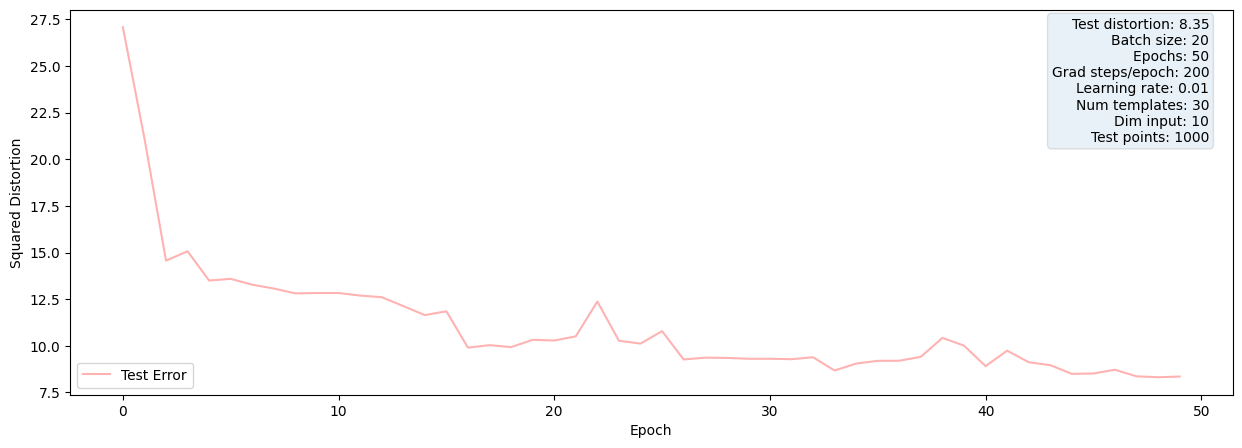

In [101]:
avg_final_error = np.mean([d[-1] for d in all_test_distortions])
print(avg_final_error)

fig = plt.figure(figsize = (15,5))

for distortion_function in all_test_distortions:
    plt.plot(distortion_function, alpha=0.3, c='red', label = 'Test Error')

textstr = '\n'.join([
    f'Test distortion: {avg_final_error:.2f}',
    f'Batch size: {batch_size}',
    f'Epochs: {n_epochs}',
    f'Grad steps/epoch: {grad_steps_per_epoch}',
    f'Learning rate: {lr}',
    f'Num templates: {t}',
    f'Dim input: {d}',
    f'Test points: {n_test}',
])

# Place text box in upper right in axes coords
props = dict(boxstyle='round', alpha=0.1)
plt.gca().text(0.98, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', horizontalalignment='right', bbox=props)

plt.xlabel("Epoch")
plt.ylabel("Squared Distortion")
plt.legend()

# Train Linear Layer, Random MF

In [163]:
all_test_distortions = []
all_trained_templates = []
all_trained_Ls = []

for trial in range(n_trials):
    test_distortions = []

    # max filter template layer
    templates = torch.normal(0, 1, (t, d), device=device)
    # linear layer
    L = torch.normal(0,1,(target_dim, t),requires_grad=True, device=device)

    optimizer = torch.optim.Adam([L, templates], lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    for epoch in range(n_epochs):
        for step in range(grad_steps_per_epoch):
            optimizer.zero_grad()

            # Sample training batch
            X =  torch.normal(0, 1, (d, batch_size), device=device)
            D = G.dist_matrix(X)           # Tensor (n, n)
            X_orbits = G.get_orbits(X)     # Tensor (k, d, n)

            # Forward pass
            norm_templates = F.normalize(templates, dim=1)
            filter_features = max_filter(norm_templates, X_orbits)
            features = L @ filter_features

            alpha_sq, beta_sq = squared_lipschitz(D, features)
            loss = beta_sq / alpha_sq

            loss.backward()
            optimizer.step()
            print(f"Gradient step {step}", end='\r')

        # Test each epoch
        with torch.no_grad():
            norm_templates = F.normalize(templates, dim=1)
            test_features = max_filter(norm_templates, X_test_orbits)
            test_features = L @ test_features
            alpha_test_sq, beta_test_sq = squared_lipschitz(D_test, test_features)
            distortion_test = (beta_test_sq / alpha_test_sq).item()

            print(f"Trial {trial+1}, Epoch {epoch+1} — Test Distortion²: {distortion_test:.4f}")
            test_distortions.append(distortion_test)

        scheduler.step()

    all_test_distortions.append(test_distortions)
    all_trained_templates.append(norm_templates.detach().cpu().numpy())
    all_trained_Ls.append(L.detach().cpu().numpy())

Trial 1, Epoch 1 — Test Distortion²: 23.3713
Trial 1, Epoch 2 — Test Distortion²: 17.8542
Trial 1, Epoch 3 — Test Distortion²: 15.8552
Trial 1, Epoch 4 — Test Distortion²: 15.6544
Trial 1, Epoch 5 — Test Distortion²: 14.4170
Trial 1, Epoch 6 — Test Distortion²: 14.4623
Trial 1, Epoch 7 — Test Distortion²: 13.8353
Trial 1, Epoch 8 — Test Distortion²: 15.2828
Trial 1, Epoch 9 — Test Distortion²: 16.4304
Trial 1, Epoch 10 — Test Distortion²: 15.3105
Trial 1, Epoch 11 — Test Distortion²: 16.0259
Trial 1, Epoch 12 — Test Distortion²: 15.5841
Trial 1, Epoch 13 — Test Distortion²: 14.6163
Trial 1, Epoch 14 — Test Distortion²: 15.0264
Trial 1, Epoch 15 — Test Distortion²: 14.4020
Trial 1, Epoch 16 — Test Distortion²: 14.8353
Trial 1, Epoch 17 — Test Distortion²: 14.1433
Trial 1, Epoch 18 — Test Distortion²: 13.6601
Trial 1, Epoch 19 — Test Distortion²: 13.3097
Trial 1, Epoch 20 — Test Distortion²: 13.1138
Trial 1, Epoch 21 — Test Distortion²: 14.6599
Trial 1, Epoch 22 — Test Distortion²: 14.07

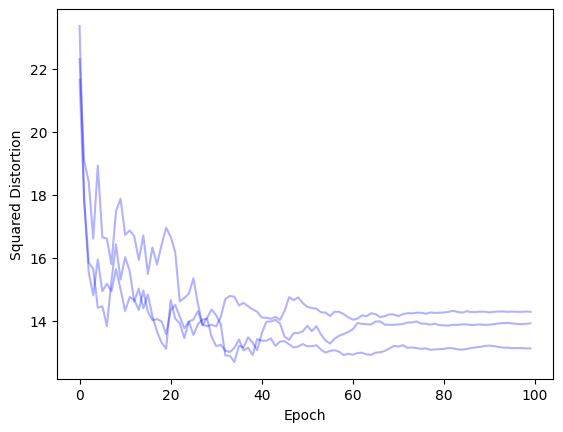

In [164]:
for distortion_function in all_test_distortions:
    plt.plot(distortion_function, alpha=0.3, c='blue')
plt.xlabel("Epoch")
plt.ylabel("Squared Distortion")
plt.show()

# Train MF, no linear 

In [165]:
all_test_distortions = []
all_trained_templates = []
all_trained_Ls = []

for trial in range(n_trials):
    test_distortions = []

    # max filter template layer
    templates = torch.normal(0, 1, (t, d),requires_grad=True, device=device)

    optimizer = torch.optim.Adam([templates], lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    for epoch in range(n_epochs):
        for step in range(grad_steps_per_epoch):
            optimizer.zero_grad()

            # Sample training batch
            X =  torch.normal(0, 1, (d, batch_size), device=device)
            D = G.dist_matrix(X)           # Tensor (n, n)
            X_orbits = G.get_orbits(X)     # Tensor (k, d, n)

            # Forward pass
            norm_templates = F.normalize(templates, dim=1)
            filter_features = max_filter(norm_templates, X_orbits)
            features = filter_features

            alpha_sq, beta_sq = squared_lipschitz(D, features)
            loss = beta_sq / alpha_sq

            loss.backward()
            optimizer.step()
            print(f"Gradient step {step}", end='\r')

        # Test each epoch
        with torch.no_grad():
            norm_templates = F.normalize(templates, dim=1)
            test_features = max_filter(norm_templates, X_test_orbits)
            test_features = test_features
            alpha_test_sq, beta_test_sq = squared_lipschitz(D_test, test_features)
            distortion_test = (beta_test_sq / alpha_test_sq).item()

            print(f"Trial {trial+1}, Epoch {epoch+1} — Test Distortion²: {distortion_test:.4f}")
            test_distortions.append(distortion_test)
        scheduler.step()

    all_test_distortions.append(test_distortions)
    all_trained_templates.append(norm_templates.detach().cpu().numpy())
    all_trained_Ls.append(L.detach().cpu().numpy())

Trial 1, Epoch 1 — Test Distortion²: 8.3703
Trial 1, Epoch 2 — Test Distortion²: 9.6519
Trial 1, Epoch 3 — Test Distortion²: 9.2912
Trial 1, Epoch 4 — Test Distortion²: 9.2151
Trial 1, Epoch 5 — Test Distortion²: 9.4745
Trial 1, Epoch 6 — Test Distortion²: 9.1404
Trial 1, Epoch 7 — Test Distortion²: 7.8205
Trial 1, Epoch 8 — Test Distortion²: 8.2331
Trial 1, Epoch 9 — Test Distortion²: 7.7115
Trial 1, Epoch 10 — Test Distortion²: 6.9022
Trial 1, Epoch 11 — Test Distortion²: 7.3157
Trial 1, Epoch 12 — Test Distortion²: 7.3563
Trial 1, Epoch 13 — Test Distortion²: 7.8593
Trial 1, Epoch 14 — Test Distortion²: 7.1843
Trial 1, Epoch 15 — Test Distortion²: 7.5307
Trial 1, Epoch 16 — Test Distortion²: 7.0507
Trial 1, Epoch 17 — Test Distortion²: 7.0632
Trial 1, Epoch 18 — Test Distortion²: 7.0488
Trial 1, Epoch 19 — Test Distortion²: 7.5306
Trial 1, Epoch 20 — Test Distortion²: 7.3067
Trial 1, Epoch 21 — Test Distortion²: 7.2831
Trial 1, Epoch 22 — Test Distortion²: 7.4895
Trial 1, Epoch 23 —

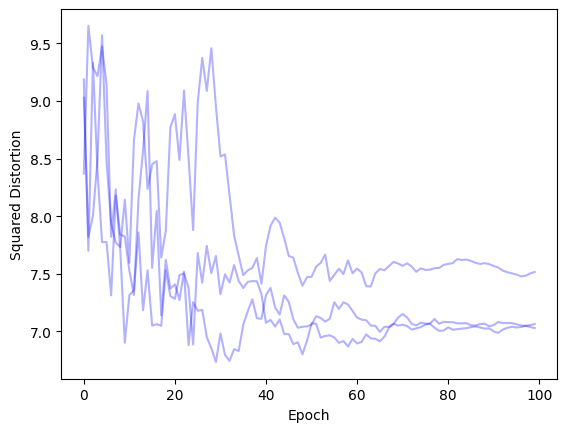

In [166]:
for distortion_function in all_test_distortions:
    plt.plot(distortion_function, alpha=0.3, c='blue')
plt.xlabel("Epoch")
plt.ylabel("Squared Distortion")
plt.show()

# Just random MF 

In [167]:
all_test_distortions = []
all_trained_templates = []
all_trained_Ls = []

for trial in range(n_trials):
    test_distortions = []

    # max filter template layer
    templates = torch.normal(0, 1, (t, d), device=device)
    
    with torch.no_grad():
        norm_templates = F.normalize(templates, dim=1)
        test_features = max_filter(norm_templates, X_test_orbits)
        alpha_test_sq, beta_test_sq = squared_lipschitz(D_test, test_features)
        distortion_test = (beta_test_sq / alpha_test_sq).item()

        print(f"Trial {trial+1}, Epoch {epoch+1} — Test Distortion²: {distortion_test:.4f}")
        test_distortions.append(distortion_test)

    all_test_distortions.append(test_distortions)
    all_trained_templates.append(norm_templates.detach().cpu().numpy())
    all_trained_Ls.append(L.detach().cpu().numpy())

Trial 1, Epoch 100 — Test Distortion²: 22.6259
Trial 2, Epoch 100 — Test Distortion²: 18.1433
Trial 3, Epoch 100 — Test Distortion²: 23.8788


# Viewing Optimal Templates d=3

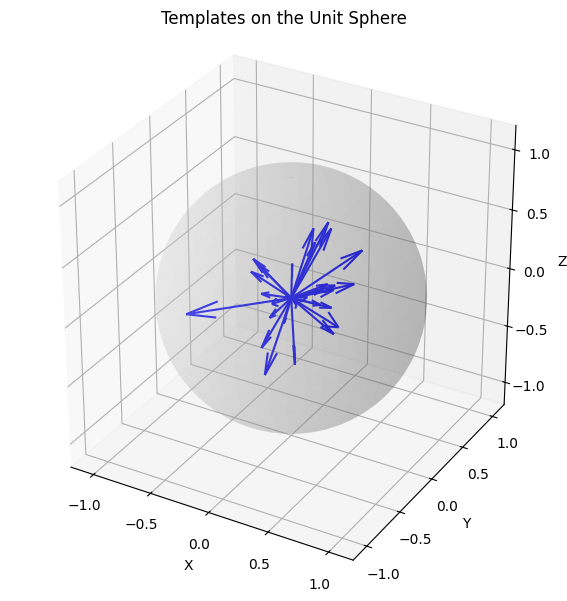

In [168]:
T = norm_templates.detach().cpu().numpy().T  # Shape: (3, t)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the unit sphere
u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:100j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.2, linewidth=0)

# Plot each vector from the origin
origin = np.zeros((3, t))
ax.quiver(
    origin[0], origin[1], origin[2],
    T[0], T[1], T[2],
    color='blue', length=1.0, normalize=False, linewidth=1.5
)

# Formatting
ax.set_box_aspect([1, 1, 1])  # Equal aspect ratio
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Templates on the Unit Sphere')

plt.tight_layout()
plt.show()

# G-Max NN: $L \cdot MaxPool(Z\cdot ReLU(W \cdot X_{orbits}))$

In [369]:
all_test_distortions = []
all_trained_templates = []
all_trained_Ls = []

for trial in range(n_trials):
    test_distortions = []

    # layers
    templates = torch.normal(0, 1, (t, d), requires_grad=True, device=device)
    L = torch.normal(0, 1, (target_dim, t), requires_grad=True, device=device)
    W = torch.normal(0, 1, (d, d), requires_grad=True, device=device)  # input linear transform

    optimizer = torch.optim.Adam([W, L, templates], lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    for epoch in range(n_epochs):
        for step in range(grad_steps_per_epoch):
            optimizer.zero_grad()

            # Sample training batch
            X = torch.normal(0, 1, (d, batch_size), device=device)                        # (d', batch_size)
            D = G.dist_matrix(X)                     # (n, n)
            X_orbits = G.get_orbits(X)               # (k, d', n)
            Y_orbits = F.relu(torch.einsum('dd,kdn->kdn', W, X_orbits))
            
            # Forward pass
            norm_templates = F.normalize(templates, dim=1)       # (t, d)
            filter_features = max_filter(norm_templates, Y_orbits)  # (t, batch_size)
            features = L @ filter_features                        # (target_dim, batch_size)

            alpha_sq, beta_sq = squared_lipschitz(D, features)
            loss = beta_sq / alpha_sq

            loss.backward()
            optimizer.step()
            print(f"Gradient step {step}", end='\r')

        # Test each epoch
        with torch.no_grad():
            Y_test_orbits = F.relu(torch.einsum('dd,kdn->kdn', W, X_test_orbits))             # (d', test_batch_size)
            norm_templates = F.normalize(templates, dim=1)
            test_features = max_filter(norm_templates, Y_test_orbits)  # (t, test_batch_size)
            test_features = L @ test_features                        # (target_dim, test_batch_size)

            alpha_test_sq, beta_test_sq = squared_lipschitz(D_test, test_features)
            distortion_test = (beta_test_sq / alpha_test_sq).item()

            print(f"Trial {trial+1}, Epoch {epoch+1} — Test Distortion²: {distortion_test:.4f}")
            test_distortions.append(distortion_test)
        scheduler.step()

    all_test_distortions.append(test_distortions)
    all_trained_templates.append(norm_templates.detach().cpu().numpy())
    all_trained_Ls.append(L.detach().cpu().numpy())

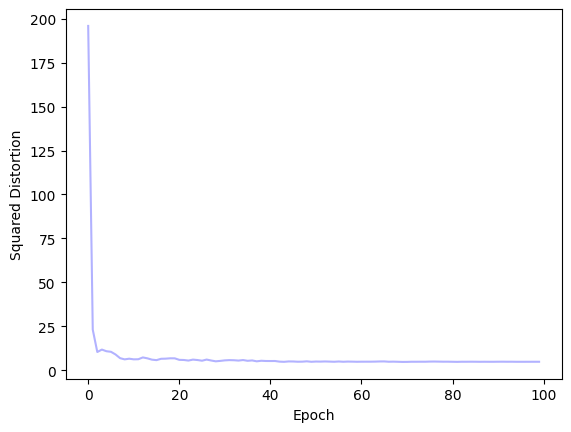

In [189]:
for distortion_function in all_test_distortions:
    plt.plot(distortion_function, alpha=0.3, c='blue')
plt.xlabel("Epoch")
plt.ylabel("Squared Distortion")
plt.show()

In [321]:
#Create a random test set n pts in d dim
n_test = 1000
d = 3
# number of templates in max filter
t = 3*d
# currently maintain dimensionality given by max filtering
target_dim = t
G = GPU_GroupAction(pmId, d, device=device)

X_test = torch.normal(0, 1, size=(d, n_test), device=device)
X_test_orbits = G.get_orbits(X_test)
D_test = G.dist_matrix(X_test)
D_test_expanded = D_test.repeat(k,k)

batch_size = 20 # 20 works well for pmId d=3
n_trials = 1 #The number of times we will train a new model from scratch
n_epochs = 10 #The number of training epochs for each model
grad_steps_per_epoch = 200 #The number of gradient descent iterations in each training epoch
lr = 1e-2# learning rate default 1e-3
lr_period = n_epochs

# ML Bro 1 Layer RELU NN 

In [298]:
all_test_distortions = []
all_trained_distortions = []
all_trained_Ws = []
all_trained_Ls = []

k = G.order
hidden_dim = k*target_dim
for trial in range(n_trials):
    test_distortions = []
    train_distortions = []

    # Initialize weights with good scaling
    W = torch.normal(0, 1, (hidden_dim, d), requires_grad=True, device=device)
    L = torch.normal(0, 1, (target_dim, hidden_dim), requires_grad=True, device=device)

    optimizer = torch.optim.Adam([W, L], lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, lr_period)

    for epoch in range(n_epochs):
        for step in range(grad_steps_per_epoch):
            optimizer.zero_grad()

            # Sample training batch
            X = torch.normal(0, 1, (d, batch_size), device=device)
            D = G.dist_matrix(X)            # shape: (n, n), squared distances
            # create k*n by k*n distance matrix for spun up data-set
            D_expanded = D.repeat(k,k)
            X_orbits = G.get_orbits(X)      # shape: (k, d, n)

            # Reshape orbits into separate samples
            X_orbits_reshaped = (X_orbits.permute(1, 0, 2).reshape(d, k*X_orbits.shape[2]))  # (d, k*n)

            # Forward pass
            hidden = F.relu(W @ X_orbits_reshaped)        # (hidden_dim, k*n)
            features = L @ hidden                         # (target_dim, k*n)

            # Lipschitz loss
            alpha_sq, beta_sq = squared_lipschitz_orbits(D_expanded, features, k)
            clamped_alpha_sq = torch.clamp(alpha_sq, min = 1e-16)
            clamped_beta_sq = torch.clamp(beta_sq, max = 1e16)
            loss = clamped_beta_sq / (clamped_alpha_sq)

            loss.backward()
            optimizer.step()

        # Evaluation
        print(f"Epoch {epoch}", end='\r')
        with torch.no_grad():
            # Train features
            hidden_train = F.relu(W @ X_orbits_reshaped)
            features_train = L @ hidden_train
            alpha_train_sq, beta_train_sq = squared_lipschitz_orbits(D_expanded, features_train, k)
            clamped_alpha_train_sq = torch.clamp(alpha_train_sq, min = 1e-16)
            clamped_beta_train_sq = torch.clamp(beta_train_sq, max = 1e-16)
            distortion_train = (clamped_beta_train_sq / clamped_alpha_train_sq).item()

            # Test
            X_test_orbits_reshaped = (X_test_orbits.permute(1, 0, 2).reshape(d, k*X_test_orbits.shape[2]))
            hidden_test = F.relu(W @ X_test_orbits_reshaped)
            features_test = L @ hidden_test

            alpha_test_sq, beta_test_sq = squared_lipschitz_orbits(D_test_expanded, features_test, k)
            clamped_alpha_test_sq = torch.clamp(alpha_test_sq, min = 1e-16)
            clamped_beta_test_sq = torch.clamp(beta_test_sq, max = 1e16)
            distortion_test = (clamped_beta_test_sq / clamped_alpha_test_sq).item()

            train_distortions.append(distortion_train)
            test_distortions.append(distortion_test)

        scheduler.step()

    all_trained_distortions.append(train_distortions)
    all_test_distortions.append(test_distortions)
    all_trained_Ws.append(W.detach().cpu().numpy())
    all_trained_Ls.append(L.detach().cpu().numpy())

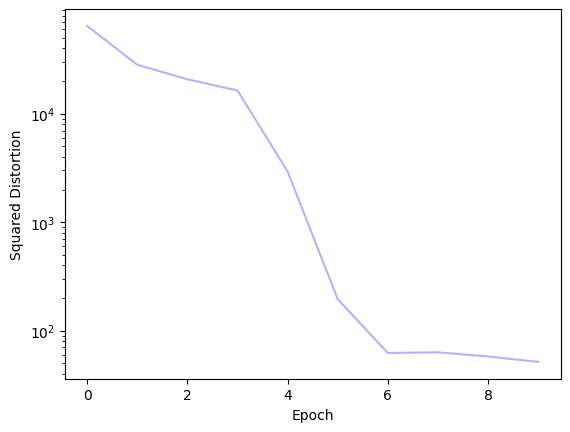

In [300]:
for distortion_function in all_test_distortions:
    plt.plot(distortion_function, alpha=0.3, c='blue')
plt.xlabel("Epoch")
plt.ylabel("Squared Distortion")
plt.yscale('log')
plt.show()

In [ ]:
# Get the last trained weights from the final trial
W = all_trained_Ws[-1]  # shape: (hidden_dim, d)
L = all_trained_Ls[-1]  # shape: (target_dim, hidden_dim)

def f(X_orbits):
    """
    Embeds orbit-expanded data as used during training.

    Args:
      X_orbits: torch.Tensor of shape (k, d, n)
                (k group elements, d input dimension, n samples)
    
    Returns:
      torch.Tensor of shape (target_dim, k * n)
    """
    # Reshape the orbits as in training
    X_orbits_reshaped = X_orbits.permute(1, 0, 2).reshape(d, -1)  # shape: (d, k * n)

    # Forward pass: two-layer linear net with ReLU
    hidden = F.relu(W @ X_orbits_reshaped)   # (hidden_dim, k * n)
    features = L @ hidden                    # (target_dim, k * n)

    return features

# Can evaluate the outputted function:
Testing shows that the outputted function is nearly group action invariant even though diagonal distances are not considered in the training loop

In [275]:
def f(X):
    # Convert PyTorch tensors to NumPy arrays
    W = all_trained_Ws[-1] if isinstance(all_trained_Ws[-1], np.ndarray) else all_trained_Ws[-1].detach().cpu().numpy()
    L = all_trained_Ls[-1] if isinstance(all_trained_Ls[-1], np.ndarray) else all_trained_Ls[-1].detach().cpu().numpy()

    # X: shape (d, n), NumPy array
    X_orbits = G.get_orbits(X)  # assumed to return NumPy array of shape (k, d, n)

    # Reshape orbits: from (k, d, n) → (d, k * n)
    X_orbits_reshaped = X_orbits.transpose(1, 0, 2).reshape(X.shape[0], -1)  # (d, k * n)

    # Forward pass: ReLU + linear layers
    hidden = np.maximum(W @ X_orbits_reshaped, 0)  # (hidden_dim, k * n)
    features = L @ hidden                          # (target_dim, k * n)

    return features

In [316]:
def sorted_filter(templates, X_orbits):
    """
    templates: (t, d)
    X_orbits:  (k, d, n)
    returns:   (k*d, n)
    """
    # inner products → (t, k, n)
    inner_products = torch.einsum('td,kdn->ktn', templates, X_orbits)
    sorted_products, _ = torch.sort(inner_products, dim=0)

    return sorted_products.reshape(-1, X_orbits.size(2))

# SORT

In [357]:
#Create a random test set n pts in d dim
n_test = 1000
d = 3
# number of templates in max filter
t = 3*d//k + 1
# currently maintain dimensionality given by max filtering
G = GPU_GroupAction(pmId, d, device=device)

X_test = torch.normal(0, 1, size=(d, n_test), device=device)
X_test_orbits = G.get_orbits(X_test)
D_test = G.dist_matrix(X_test)
D_test_expanded = D_test.repeat(k,k)

batch_size = 20 # 20 works well for pmId d=3
n_trials = 1 #The number of times we will train a new model from scratch
n_epochs = 10 #The number of training epochs for each model
grad_steps_per_epoch = 200 #The number of gradient descent iterations in each training epoch
lr = 1e-2# learning rate default 1e-3
lr_period = n_epochs

In [358]:
all_test_distortions = []
all_trained_distortions = []
all_trained_templates = []

for trial in range(n_trials):
    test_distortions = []
    train_distortions = []

    # max filter template layer
    templates = torch.normal(0, 1, (t, d), requires_grad=True, device=device)

    optimizer = torch.optim.Adam([templates], lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, lr_period)

    for epoch in range(n_epochs):
        for step in range(grad_steps_per_epoch):
            optimizer.zero_grad()

            # Sample training batch
            X =  torch.normal(0, 1, (d, batch_size), device=device)
            D = G.dist_matrix(X)           # Tensor (n, n)
            X_orbits = G.get_orbits(X)     # Tensor (k, d, n)

            # Forward pass
            norm_templates = F.normalize(templates, dim=1)
            filter_features = sorted_filter(norm_templates, X_orbits)
            features = filter_features

            alpha_sq, beta_sq = squared_lipschitz(D, features)
            loss = beta_sq / alpha_sq

            loss.backward()
            optimizer.step()

        # Test each epoch
        print(f"Epoch {epoch}", end='\r')
        with torch.no_grad():
            # Compute training distortion on last batch of training data (X, D, etc.)
            norm_templates = F.normalize(templates, dim=1)
            train_features = sorted_filter(norm_templates, X_orbits)
            alpha_train_sq, beta_train_sq = squared_lipschitz(D, train_features)
            distortion_train = (beta_train_sq / alpha_train_sq).item()

            # Compute test distortion
            test_features = sorted_filter(norm_templates, X_test_orbits)
            alpha_test_sq, beta_test_sq = squared_lipschitz(D_test, test_features)
            distortion_test = (beta_test_sq / alpha_test_sq).item()

            train_distortions.append(distortion_train)
            test_distortions.append(distortion_test)
        scheduler.step()

    all_trained_distortions.append(train_distortions)
    all_test_distortions.append(test_distortions)
    all_trained_templates.append(norm_templates.detach().cpu().numpy())

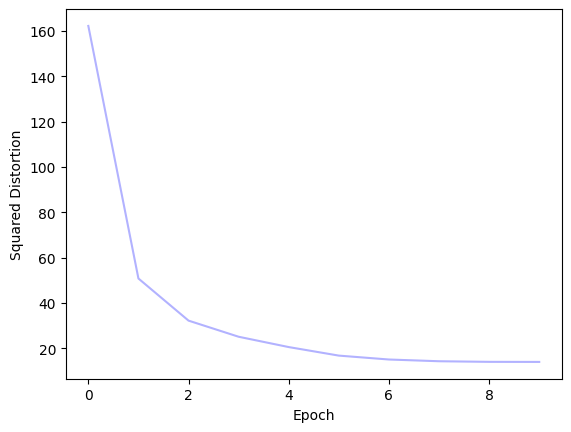

In [359]:
for distortion_function in all_test_distortions:
    plt.plot(distortion_function, alpha=0.3, c='blue')
plt.xlabel("Epoch")
plt.ylabel("Squared Distortion")
plt.show()